# 85x110 테이블 평면화 (Perspective Rectification)

`homography_table/` 폴더의 사진들은 가로 110cm x 세로 85cm(또는 그 반대 방향) 게임 테이블의
네 모서리에 초록색 테이프를 붙여 촬영한 것입니다. `holography.ipynb`의 A4 평면화 로직을 그대로
재사용하되, 목적 사각형 비율만 A4(210:297mm) 대신 테이블 실측 비율(85:110cm)로 바꿔서 적용합니다.

1. HSV 색공간에서 초록색 테이프 영역을 마스킹
2. 마스크에서 컨투어를 찾아 4개 테이프의 중심점(꼭짓점) 추출
3. 네 점을 좌상/우상/우하/좌하 순서로 정렬
4. 테이블 실제 비율(85:110cm)에 맞춘 목적 사각형을 정의하고 `cv2.getPerspectiveTransform` + `cv2.warpPerspective`로 워핑
5. 평면화 결과를 `homography_table_result/`에 저장
6. (참고: `test4.ipynb`) `best_v8.pt`로 평면화 전/후 YOLO 탐지 결과도 비교

In [ ]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "homography_table"
OUTPUT_DIR = BASE_DIR / "homography_table_result"
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

# 초록색 테이프를 검출하기 위한 HSV 범위 (필요 시 조정)
GREEN_HSV_LOWER = np.array([35, 60, 40])
GREEN_HSV_UPPER = np.array([85, 255, 255])

# 컨투어 필터링: 전체 이미지 면적 대비 테이프 영역의 최소/최대 비율
MIN_AREA_RATIO = 0.0003
MAX_AREA_RATIO = 0.05

# 테이블 실제 크기(cm)와 출력 해상도(px) 설정
TABLE_SHORT_CM = 85.0
TABLE_LONG_CM = 110.0
LONG_SIDE_PX = 1200
SHORT_SIDE_PX = round(LONG_SIDE_PX * TABLE_SHORT_CM / TABLE_LONG_CM)

if not DATA_DIR.exists():
    raise FileNotFoundError(f"이미지 폴더가 없습니다: {DATA_DIR.resolve()}")

OUTPUT_DIR.mkdir(exist_ok=True)

image_paths = sorted(
    p for p in DATA_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
)
print(f"대상 이미지: {len(image_paths)}장")
for p in image_paths:
    print(" -", p.name)

In [2]:
import matplotlib.font_manager as fm

# matplotlib 기본 폰트는 한글을 지원하지 않아 그래프 제목이 네모(□)로 깨져 보입니다.
# 1) 시스템에 이미 설치된 한글 폰트를 먼저 찾고,
# 2) 없으면 노트북 옆의 `fonts/` 폴더에 놓아둔 .ttf 파일을 찾아 등록합니다.
#    (인터넷이 안 되는 폐쇄망 서버라면, 로컬 PC의 C:\Windows\Fonts\malgun.ttf 파일을
#     이 프로젝트의 `fonts/` 폴더로 복사해 넣고 이 셀을 다시 실행하세요.)
_installed_fonts = {f.name for f in fm.fontManager.ttflist}
_font_name = next(
    (n for n in ["Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans CJK KR", "Noto Sans KR"]
     if n in _installed_fonts),
    None,
)

if _font_name is None:
    _font_dir = BASE_DIR / "fonts"
    _local_fonts = sorted(_font_dir.glob("*.ttf")) if _font_dir.exists() else []
    if _local_fonts:
        fm.fontManager.addfont(str(_local_fonts[0]))
        _font_name = fm.FontProperties(fname=str(_local_fonts[0])).get_name()
        print(f"로컬 폰트 등록: {_local_fonts[0].name} -> {_font_name}")
    else:
        print(
            "한글 폰트를 찾지 못했습니다. 그래프 제목이 깨질 수 있습니다.\n"
            f"해결하려면 한글 .ttf 폰트 파일을 '{_font_dir}' 폴더에 넣고 이 셀을 다시 실행하세요."
        )

if _font_name:
    plt.rcParams["font.family"] = _font_name

plt.rcParams["axes.unicode_minus"] = False  # 한글 폰트 사용 시 마이너스(-) 기호 깨짐 방지

In [3]:
def order_points(pts: np.ndarray) -> np.ndarray:
    """4개의 점을 좌상, 우상, 우하, 좌하 순서로 정렬합니다.

    단순 x+y/x-y 기준 정렬은 테이블이 큰 각도로 회전/기울어진 경우
    두 꼭짓점이 같은 점으로 잘못 뽑히는 경우가 있어, 중심점 기준 각도로
    정렬하는 방식(회전에 안정적)을 사용합니다.
    """
    center = pts.mean(axis=0)
    angles = np.arctan2(pts[:, 1] - center[1], pts[:, 0] - center[0])
    ordered = pts[np.argsort(angles)]

    # 정렬된 4점 중 좌상(x+y 최소)에 해당하는 점부터 시작하도록 회전
    start = np.argmin(ordered.sum(axis=1))
    ordered = np.roll(ordered, -start, axis=0)

    return ordered.astype(np.float32)


def detect_green_corners(image: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """이미지에서 초록색 테이프 4개의 중심점을 찾아 정렬된 좌표와 마스크를 반환합니다."""
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, GREEN_HSV_LOWER, GREEN_HSV_UPPER)

    kernel = np.ones((7, 7), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    image_area = image.shape[0] * image.shape[1]
    min_area = image_area * MIN_AREA_RATIO
    max_area = image_area * MAX_AREA_RATIO

    candidates = [c for c in contours if min_area <= cv2.contourArea(c) <= max_area]
    candidates = sorted(candidates, key=cv2.contourArea, reverse=True)[:4]

    if len(candidates) != 4:
        raise ValueError(
            f"초록색 테이프를 4개 찾지 못했습니다 (검출: {len(candidates)}개). "
            "GREEN_HSV_LOWER/UPPER 또는 면적 비율을 조정하세요."
        )

    centers = []
    for c in candidates:
        M = cv2.moments(c)
        cx = M["m10"] / M["m00"]
        cy = M["m01"] / M["m00"]
        centers.append([cx, cy])

    corners = order_points(np.array(centers, dtype=np.float32))
    return corners, mask

In [ ]:
def warp_to_table(image: np.ndarray, corners: np.ndarray) -> np.ndarray:
    """정렬된 4개 꼭짓점(tl, tr, br, bl)을 85x110 테이블 비율의 탑다운 뷰로 워핑합니다."""
    tl, tr, br, bl = corners

    width_top = np.linalg.norm(tr - tl)
    width_bottom = np.linalg.norm(br - bl)
    height_left = np.linalg.norm(bl - tl)
    height_right = np.linalg.norm(br - tr)

    measured_width = max(width_top, width_bottom)
    measured_height = max(height_left, height_right)

    # 측정된 가로/세로 비율이 테이블의 어느 방향(가로/세로)에 더 가까운지로 출력 방향 결정
    if measured_width >= measured_height:
        out_w, out_h = LONG_SIDE_PX, SHORT_SIDE_PX  # 가로(landscape, 110cm 변이 가로)
    else:
        out_w, out_h = SHORT_SIDE_PX, LONG_SIDE_PX  # 세로(portrait, 110cm 변이 세로)

    dst = np.array(
        [
            [0, 0],
            [out_w - 1, 0],
            [out_w - 1, out_h - 1],
            [0, out_h - 1],
        ],
        dtype=np.float32,
    )

    matrix = cv2.getPerspectiveTransform(corners, dst)
    warped = cv2.warpPerspective(image, matrix, (out_w, out_h))
    return warped


def process_image(path: Path):
    image = cv2.imread(str(path))
    if image is None:
        raise FileNotFoundError(f"이미지를 읽을 수 없습니다: {path}")

    corners, mask = detect_green_corners(image)
    warped = warp_to_table(image, corners)

    annotated = image.copy()
    labels = ["TL", "TR", "BR", "BL"]
    for (x, y), label in zip(corners, labels):
        cv2.circle(annotated, (int(x), int(y)), 12, (0, 0, 255), 3)
        cv2.putText(
            annotated, label, (int(x) + 15, int(y)),
            cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 255), 2, cv2.LINE_AA,
        )
    cv2.polylines(annotated, [corners.astype(np.int32)], True, (0, 255, 255), 2)

    return annotated, mask, warped

In [ ]:
for image_path in image_paths:
    try:
        annotated, mask, warped = process_image(image_path)
    except ValueError as e:
        print(f"[{image_path.name}] 실패: {e}")
        continue

    output_path = OUTPUT_DIR / f"{image_path.stem}_flat.jpg"
    cv2.imwrite(str(output_path), warped)
    print(f"[{image_path.name}] 저장 완료: {output_path}")

    fig, axes = plt.subplots(1, 3, figsize=(16, 6))

    axes[0].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"{image_path.name}\n원본 + 검출된 모서리")
    axes[0].axis("off")

    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title("초록색 테이프 마스크")
    axes[1].axis("off")

    axes[2].imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
    axes[2].set_title("테이블 평면화 결과 (85x110)")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

## 튜닝 가이드

- 테이프가 검출되지 않거나(`실패` 출력) 잘못된 영역이 잡히면 `GREEN_HSV_LOWER`/`GREEN_HSV_UPPER` 값을 조정하세요.
  가운데 마스크 이미지(`초록색 테이프 마스크`)를 보면서 테이프 4개만 하얗게 나오도록 맞추면 됩니다.
- 테이프 외에 다른 초록색 물체가 같이 잡히면 `MIN_AREA_RATIO` / `MAX_AREA_RATIO`로 면적 범위를 좁히세요.
- 출력 해상도를 바꾸고 싶으면 `LONG_SIDE_PX` 값만 조정하면 `SHORT_SIDE_PX`가 테이블 비율(85:110)에 맞춰 자동 계산됩니다.
- 테이블 실측 크기가 다르면 `TABLE_SHORT_CM` / `TABLE_LONG_CM` 값만 바꾸면 됩니다.
- 평면화 결과는 `homography_table_result/` 폴더에 `{원본파일명}_flat.jpg`로 자동 저장됩니다.

## 원본 vs 평면화 이미지 YOLO 탐지 비교

(`test4.ipynb` 참고) `homography_table/`(원본 촬영 이미지)와 방금 생성한 `homography_table_result/`
(테이블 평면화 결과)를 같은 `best_v8.pt` 모델로 각각 YOLO 탐지하여, 평면화가 타일 탐지 정확도에
어떤 영향을 주는지 나란히 비교합니다.

In [6]:
import torch
from ultralytics import YOLO

MODEL_PATH = BASE_DIR / "best_v8.pt"
RAW_DIR = DATA_DIR
FLAT_DIR = OUTPUT_DIR
CONFIDENCE = 0.25

if not MODEL_PATH.exists():
    raise FileNotFoundError(f"모델 파일이 없습니다: {MODEL_PATH.resolve()}")
if not RAW_DIR.exists():
    raise FileNotFoundError(f"원본 이미지 폴더가 없습니다: {RAW_DIR.resolve()}")
if not FLAT_DIR.exists():
    raise FileNotFoundError(f"평면화 이미지 폴더가 없습니다: {FLAT_DIR.resolve()}")

device = 0 if torch.cuda.is_available() else "cpu"
print("사용 장치:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

model = YOLO(str(MODEL_PATH))

사용 장치: cpu


In [7]:
raw_paths = sorted(
    p for p in RAW_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
)

pairs = []
for raw_path in raw_paths:
    flat_candidates = sorted(FLAT_DIR.glob(f"{raw_path.stem}_flat.*"))
    if not flat_candidates:
        print(f"[경고] {raw_path.name}에 대응하는 평면화 이미지를 찾지 못했습니다 (건너뜀).")
        continue
    pairs.append((raw_path, flat_candidates[0]))

print(f"비교할 이미지 쌍: {len(pairs)}개")
for raw_path, flat_path in pairs:
    print(f" - {raw_path.name}  <->  {flat_path.name}")

비교할 이미지 쌍: 3개
 - 485A182A-93F7-493E-879A-DCA0EBA53213.jpg  <->  485A182A-93F7-493E-879A-DCA0EBA53213_flat.jpg
 - AEFB8776-0C31-454F-9AB4-545840C7B2D6.jpg  <->  AEFB8776-0C31-454F-9AB4-545840C7B2D6_flat.jpg
 - F249CD50-4C4C-4C33-840E-9F8222D5CB55.jpg  <->  F249CD50-4C4C-4C33-840E-9F8222D5CB55_flat.jpg


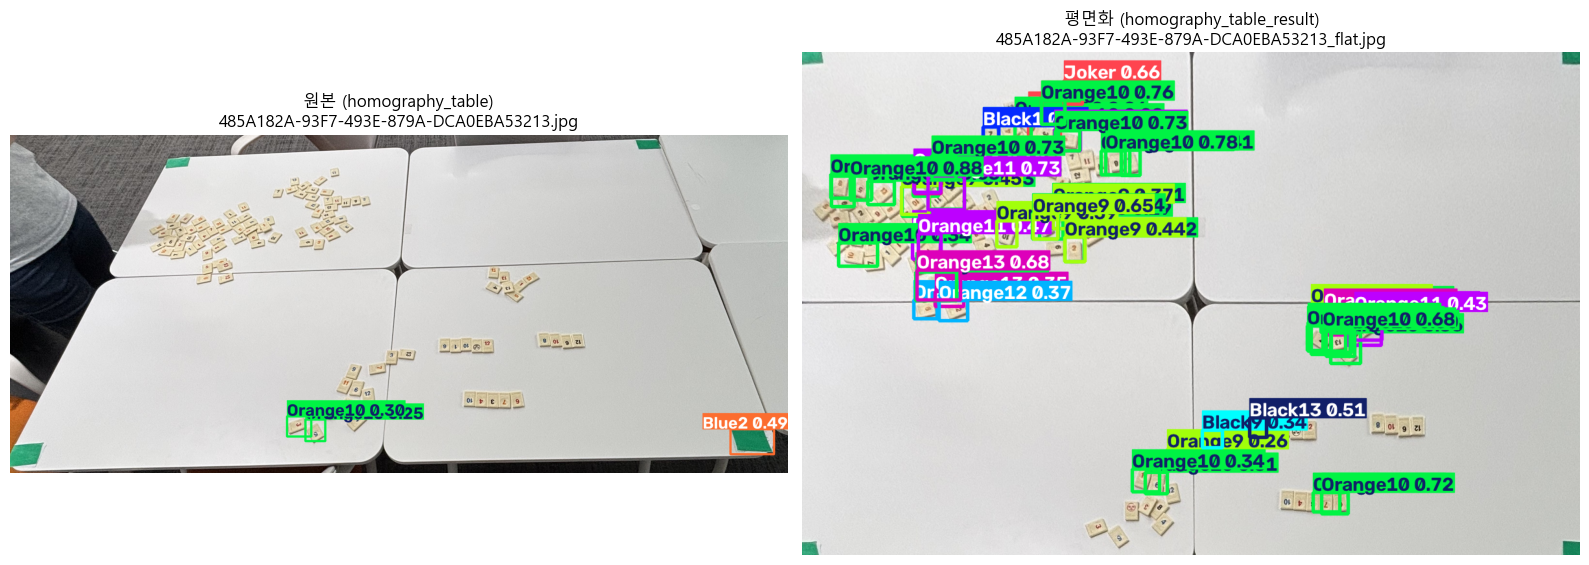

[485A182A-93F7-493E-879A-DCA0EBA53213]
  [원본] 탐지 3개:
    - Blue2: 0.49
    - Orange10: 0.30
    - Orange10: 0.25
  [평면화] 탐지 60개:
    - Orange10: 0.88
    - Orange10: 0.78
    - Orange10: 0.76
    - Orange10: 0.73
    - Orange11: 0.73
    - Orange10: 0.73
    - Orange10: 0.72
    - Orange10: 0.68
    - Orange13: 0.68
    - Orange10: 0.67
    - Orange10: 0.67
    - Joker: 0.66
    - Orange10: 0.65
    - Orange9: 0.65
    - Orange10: 0.64
    - Orange11: 0.62
    - Orange10: 0.59
    - Joker: 0.59
    - Orange9: 0.59
    - Orange13: 0.56
    - Orange10: 0.55
    - Black13: 0.51
    - Orange10: 0.50
    - Orange11: 0.47
    - Orange9: 0.45
    - Orange10: 0.45
    - Orange9: 0.44
    - Orange10: 0.43
    - Orange11: 0.43
    - Orange10: 0.42
    - Orange10: 0.41
    - Orange10: 0.41
    - Orange9: 0.39
    - Orange9: 0.37
    - Orange12: 0.37
    - Orange11: 0.37
    - Orange10: 0.36
    - Orange10: 0.36
    - Orange10: 0.35
    - Orange13: 0.35
    - Black9: 0.34
    - Orange10: 0.34
    

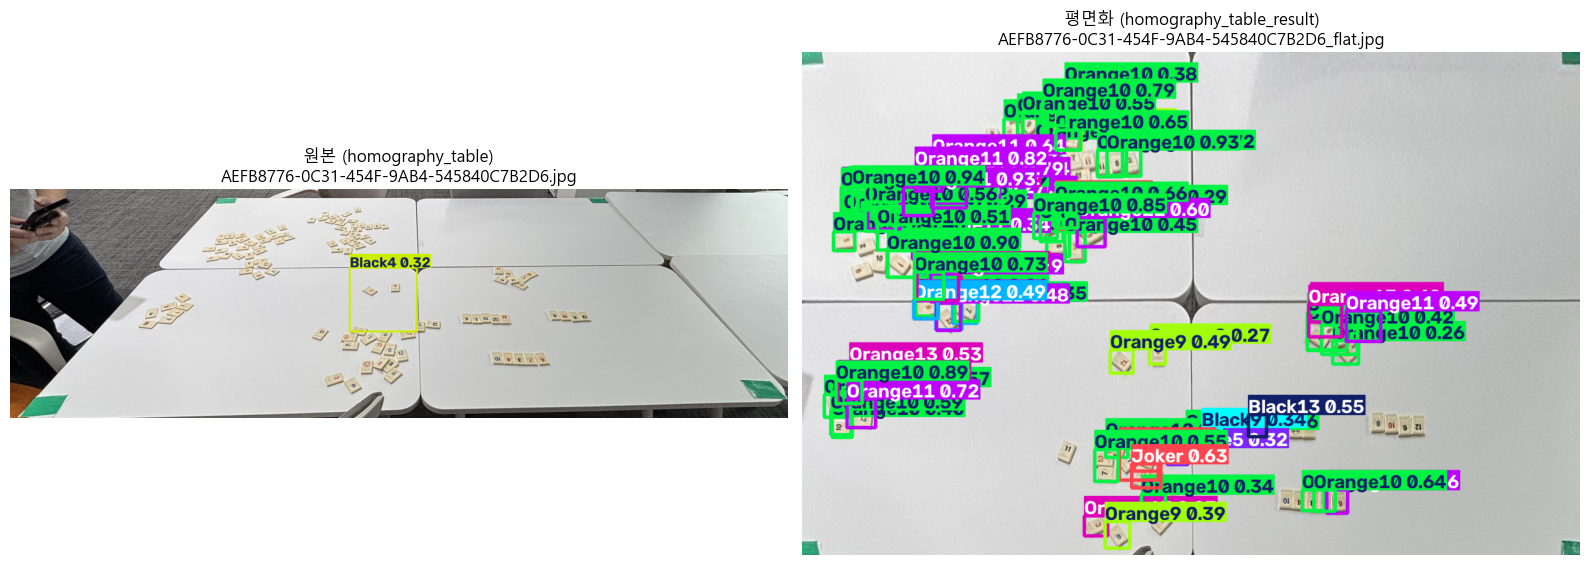

[AEFB8776-0C31-454F-9AB4-545840C7B2D6]
  [원본] 탐지 1개:
    - Black4: 0.32
  [평면화] 탐지 98개:
    - Orange10: 0.94
    - Orange11: 0.93
    - Orange10: 0.93
    - Orange10: 0.90
    - Orange10: 0.89
    - Orange10: 0.85
    - Orange11: 0.82
    - Orange11: 0.79
    - Orange10: 0.79
    - Orange10: 0.75
    - Orange10: 0.73
    - Orange10: 0.72
    - Orange11: 0.72
    - Orange13: 0.70
    - Orange13: 0.69
    - Orange10: 0.68
    - Orange10: 0.66
    - Orange10: 0.65
    - Orange11: 0.64
    - Orange10: 0.64
    - Joker: 0.63
    - Joker: 0.63
    - Orange11: 0.60
    - Orange10: 0.59
    - Orange10: 0.57
    - Orange10: 0.56
    - Orange11: 0.56
    - Black13: 0.55
    - Orange10: 0.55
    - Orange10: 0.55
    - Orange13: 0.54
    - Orange10: 0.54
    - Orange13: 0.53
    - Orange10: 0.52
    - Orange10: 0.51
    - Joker: 0.51
    - Orange10: 0.50
    - Orange11: 0.50
    - Orange11: 0.49
    - Orange12: 0.49
    - Orange10: 0.49
    - Orange9: 0.49
    - Orange11: 0.48
    - Orange10: 0.46

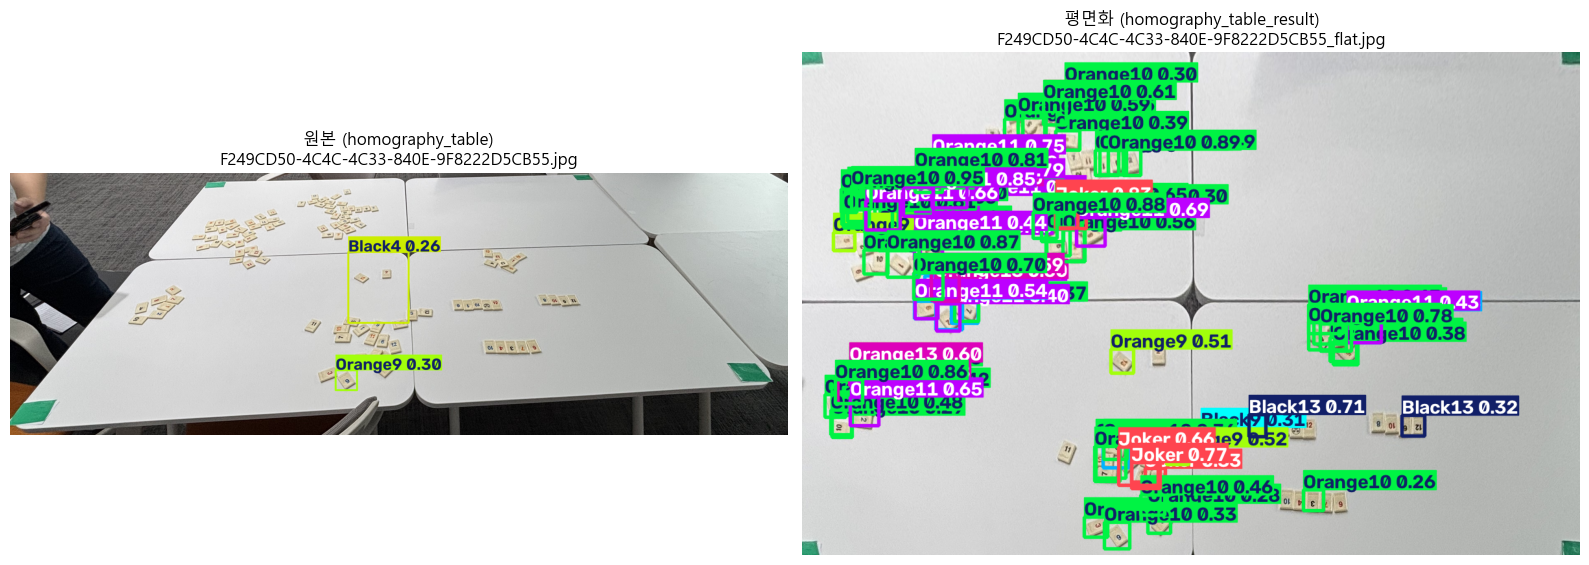

[F249CD50-4C4C-4C33-840E-9F8222D5CB55]
  [원본] 탐지 2개:
    - Orange9: 0.30
    - Black4: 0.26
  [평면화] 탐지 98개:
    - Orange10: 0.95
    - Orange10: 0.89
    - Orange10: 0.88
    - Orange10: 0.87
    - Orange10: 0.86
    - Orange11: 0.85
    - Joker: 0.83
    - Orange10: 0.81
    - Orange11: 0.79
    - Orange10: 0.78
    - Orange13: 0.78
    - Joker: 0.77
    - Orange11: 0.75
    - Black13: 0.71
    - Orange10: 0.71
    - Orange10: 0.70
    - Orange11: 0.69
    - Joker: 0.67
    - Joker: 0.66
    - Orange11: 0.66
    - Orange10: 0.65
    - Orange11: 0.65
    - Orange10: 0.65
    - Orange10: 0.61
    - Orange10: 0.61
    - Orange10: 0.61
    - Orange13: 0.60
    - Orange10: 0.60
    - Orange13: 0.59
    - Orange10: 0.59
    - Orange13: 0.58
    - Orange10: 0.57
    - Orange10: 0.56
    - Orange10: 0.54
    - Orange11: 0.54
    - Orange9: 0.52
    - Orange9: 0.51
    - Orange11: 0.50
    - Orange12: 0.50
    - Orange13: 0.50
    - Orange13: 0.50
    - Orange11: 0.50
    - Orange10: 0.49
    

In [8]:
def _print_detections(label: str, result) -> int:
    boxes = result.boxes
    count = len(boxes) if boxes is not None else 0
    if count > 0:
        print(f"  [{label}] 탐지 {count}개:")
        for cls_id, conf in zip(boxes.cls.tolist(), boxes.conf.tolist()):
            print(f"    - {result.names[int(cls_id)]}: {conf:.2f}")
    else:
        print(f"  [{label}] 탐지된 객체 없음")
    return count


summary = []

for raw_path, flat_path in pairs:
    raw_result = model.predict(source=str(raw_path), conf=CONFIDENCE, device=device, verbose=False)[0]
    flat_result = model.predict(source=str(flat_path), conf=CONFIDENCE, device=device, verbose=False)[0]

    raw_annotated = cv2.cvtColor(raw_result.plot(), cv2.COLOR_BGR2RGB)
    flat_annotated = cv2.cvtColor(flat_result.plot(), cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    axes[0].imshow(raw_annotated)
    axes[0].set_title(f"원본 (homography_table)\n{raw_path.name}")
    axes[0].axis("off")

    axes[1].imshow(flat_annotated)
    axes[1].set_title(f"평면화 (homography_table_result)\n{flat_path.name}")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

    print(f"[{raw_path.stem}]")
    raw_count = _print_detections("원본", raw_result)
    flat_count = _print_detections("평면화", flat_result)
    print()

    summary.append((raw_path.stem, raw_count, flat_count))

In [9]:
print(f"{'파일':40s} {'원본 탐지수':>10s} {'평면화 탐지수':>12s}")
for stem, raw_count, flat_count in summary:
    print(f"{stem:40s} {raw_count:>10d} {flat_count:>12d}")

파일                                           원본 탐지수      평면화 탐지수
485A182A-93F7-493E-879A-DCA0EBA53213              3           60
AEFB8776-0C31-454F-9AB4-545840C7B2D6              1           98
F249CD50-4C4C-4C33-840E-9F8222D5CB55              2           98
